# Rent Increase Modelling Exploration
This notebook explores the factors driving rent increases using lease history and asking rent data.

### Engineered Feature Glossary

To build a robust, context-aware pricing strategy, several micro and macro features were engineered and injected into the model:

**Internal (Micro) Metrics:**
* **`Market_Gap` (Loss-to-Lease):** The difference between the unit's current market asking rent and what the tenant was previously paying. This measures the immediate financial incentive to raise the rent.
* **`Market_Velocity` (Internal Momentum):** The 12-month trailing percentage change in the internal asking rent for a specific unit. This tells us if building management is actively pushing retail prices up or if they are stagnating.

**External (Macro) Metrics (Sourced from CMHC):**
* **`Vacancy_Rate_Pct` (Macro Elasticity):** The city-wide vacancy rate for the specific unit type. High vacancy signals a "soft" market where aggressive rent increases risk high tenant churn.
* **`CMHC_Market_Premium` (Strategic Positioning):** A comparison of our internal rent to the CMHC city average `(Our_Rent - CMHC_Avg) / CMHC_Avg`. This reveals if the building is a "Premium Product" (highly elastic tenants with cheaper alternatives) or a "Value Product" (inelastic tenants).
* **`Rent_YoY_Growth_Pct` (Market Trend):** The Year-over-Year percentage growth of average rents in the broader city. Captures macroeconomic momentum.

**Geographic Strategy Flags:**
* **`sBuilding` & `sState`:** Dummy-encoded identifiers that allow the Random Forest to adjust the baseline strategy depending on a building's specific pricing power and a province's legislative rent control environment.

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

%matplotlib inline

## 1. Load Data
Loading the lease history and asking rent datasets.

In [198]:
data_dir = "data/"
lease_df = pd.read_csv(data_dir + "equinoxe_lease_history.csv")
asking_df = pd.read_csv(data_dir + "equinoxe_asking_history.csv")
print(f"Lease History Shape: {lease_df.shape}")
print(f"Asking History Shape: {asking_df.shape}")

Lease History Shape: (4302, 35)
Asking History Shape: (3857, 14)


## 1.5 Merge Concessions Data
We process the historical concessions to extract boolean flags for each lease (e.g. `Conc_PromoPay`). This will allow us to track 'Concession Cliffs' when an upfront promo disappears at renewal.

In [199]:
conc_df = pd.read_csv(data_dir + 'equinoxe_concessions.csv')
conc_df['sDateFrom'] = pd.to_datetime(conc_df['sDateFrom'])
conc_df['sAmount'] = conc_df['sAmount'].fillna(0)

# Pivot concessions
conc_sorted = conc_df.sort_values('sDateFrom')
conc_dummies = pd.get_dummies(conc_sorted['sChargeCode'], prefix='Conc')
conc_processed = pd.concat([conc_sorted[['hUnit', 'sDateFrom']], conc_dummies], axis=1)

# Get max for flags, sum for dollar amounts
conc_amt = conc_sorted.groupby(['hUnit', 'sDateFrom'])['sAmount'].sum().reset_index()
conc_processed = conc_processed.groupby(['hUnit', 'sDateFrom']).max().reset_index()
conc_processed = pd.merge(conc_processed, conc_amt, on=['hUnit', 'sDateFrom'])
conc_processed = conc_processed.sort_values('sDateFrom')

# Merge onto lease_df
lease_df['sLeaseFrom_dt'] = pd.to_datetime(lease_df['sLeaseFrom'])
lease_sorted = lease_df.sort_values('sLeaseFrom_dt')

lease_df = pd.merge_asof(
    lease_sorted,
    conc_processed,
    by='hUnit',
    left_on='sLeaseFrom_dt',
    right_on='sDateFrom',
    direction='backward',
    tolerance=pd.Timedelta('365D')
)

concession_cols = [c for c in lease_df.columns if c.startswith('Conc_')]
lease_df[concession_cols] = lease_df[concession_cols].fillna(0).astype(int)
lease_df['sAmount'] = lease_df['sAmount'].fillna(0)
print(f"Added {len(concession_cols)} concession flags and dollar magnitude.")

Added 8 concession flags and dollar magnitude.


## 2. Target Variable Calculation
Calculate the percentage base rent increase from the previous lease term for each unit.

In [200]:
# Flag for 'Lease-Up' Strategy vs 'Established' Buildings
established_buildings = ['Daniel-Johnson', 'Levesque']
established_prop_codes = ['stelz1', 'stelz2'] # stelz3 is brand new!

def is_lease_up(row):
    b = str(row['sBuilding']).strip()
    p = str(row['sPropCode']).strip()
    if b in established_buildings:
        return 0
    elif b == 'Saint-Elzear' and p in established_prop_codes:
        return 0
    else:
        return 1

lease_df['Is_LeaseUp'] = lease_df.apply(is_lease_up, axis=1)

# Keep relevant features
keep_cols = ['Is_LeaseUp', 'hUnit', 'sBuilding', 'sCity', 'sState', 'sTermSeq', 'sRent', 'sRentEffective', 'sBeds', 'sBaths', 'sSqft', 'sUnitType', 'sRenewal', 'sLeaseFrom', 'sTermMonths', 'sAmount'] + concession_cols
lease_df = lease_df[keep_cols].copy()

# Date parsing for seasonality
lease_df['sLeaseFrom'] = pd.to_datetime(lease_df['sLeaseFrom'])
lease_df['LeaseMonth'] = lease_df['sLeaseFrom'].dt.month.astype(str) # Convert to string for dummy encoding later
lease_df['MergeMonth'] = lease_df['sLeaseFrom'].dt.to_period('M').astype(str)




# Sort and calculate previous rent and previous concessions
lease_df = lease_df.sort_values(by=['hUnit', 'sTermSeq'])
lease_df['Previous_sRentEffective'] = lease_df.groupby('hUnit')['sRentEffective'].shift(1)
lease_df['Previous_sAmount'] = lease_df.groupby('hUnit')['sAmount'].shift(1)
lease_df['Previous_sLeaseFrom'] = lease_df.groupby('hUnit')['sLeaseFrom'].shift(1)

# Calculate Concession Ratio magnitude
lease_df['Previous_Concession_Ratio'] = lease_df['Previous_sAmount'].abs() / (lease_df['Previous_sRentEffective'] * 12)
lease_df['Previous_Concession_Ratio'] = lease_df['Previous_Concession_Ratio'].fillna(0)

for col in concession_cols:
    lease_df[f'Previous_{col}'] = lease_df.groupby('hUnit')[col].shift(1)

# Drop first term sequences (no previous rent to compare to)
model_df = lease_df.dropna(subset=['Previous_sRentEffective']).copy()
for col in concession_cols:
    model_df[f'Previous_{col}'] = model_df[f'Previous_{col}'].fillna(0).astype(int)

# Target: Percentage Increase (Effective)
# Target: Annualized Compound Growth Rate (growth_pct)
model_df['gap_years'] = (model_df['sLeaseFrom'] - model_df['Previous_sLeaseFrom']).dt.days / 365.25
# Prevent division by zero or extreme values if gap is too small
model_df = model_df[model_df['gap_years'] >= 0.1].copy()
model_df['growth_pct'] = ((model_df['sRentEffective'] / model_df['Previous_sRentEffective']) ** (1 / model_df['gap_years']) - 1) * 100
print(f"Number of valid leases for modeling: {len(model_df)}")

Number of valid leases for modeling: 3241


## 3. Merge with Market Asking Data
Calculate the 'Market Gap' by finding the most recent asking rent for the unit right before the new lease start.

In [201]:
asking_df = asking_df[['hUnit', 'sMonth', 'sAskingRent']].copy()

# Prepare datetime keys for merge_asof
asking_df['sMonth_dt'] = pd.to_datetime(asking_df['sMonth'] + '-01')
model_df['sLeaseFrom_dt'] = pd.to_datetime(model_df['MergeMonth'] + '-01')
model_df['sLeaseFrom_dt_minus_12m'] = model_df['sLeaseFrom_dt'] - pd.DateOffset(months=12)

asking_sorted = asking_df.sort_values('sMonth_dt')
model_sorted = model_df.sort_values('sLeaseFrom_dt')

# Merge asof: get the closest asking rent prior to the lease date
merged_df = pd.merge_asof(
    model_sorted, 
    asking_sorted, 
    by='hUnit', 
    left_on='sLeaseFrom_dt', 
    right_on='sMonth_dt', 
    direction='backward'
)

# Merge asof: get the asking rent from ~12 months ago to calculate velocity
merged_df = pd.merge_asof(
    merged_df.sort_values('sLeaseFrom_dt_minus_12m'), 
    asking_sorted, 
    by='hUnit', 
    left_on='sLeaseFrom_dt_minus_12m', 
    right_on='sMonth_dt', 
    direction='backward',
    suffixes=('', '_12m_ago')
)

# Restore sort order
merged_df = merged_df.sort_values(['hUnit', 'sTermSeq'])

# 1. Calculate Market Gap (Loss-to-Lease)
merged_df['Market_Gap'] = merged_df['sAskingRent'] - merged_df['Previous_sRentEffective']
merged_df['Market_Gap'] = merged_df['Market_Gap'].fillna(0) # If no asking rent is found, assume 0 gap

# 2. Calculate Market Velocity (12-month trailing change in asking rent)
merged_df['Market_Velocity'] = (merged_df['sAskingRent'] - merged_df['sAskingRent_12m_ago']) / merged_df['sAskingRent_12m_ago']
merged_df['Market_Velocity'] = merged_df['Market_Velocity'].fillna(0) 

merged_df.head()

,Is_LeaseUp,hUnit,sBuilding,sCity,sState,sTermSeq,sRent,sRentEffective,sBeds,sBaths,...,sLeaseFrom_dt,sLeaseFrom_dt_minus_12m,sMonth,sAskingRent,sMonth_dt,sMonth_12m_ago,sAskingRent_12m_ago,sMonth_dt_12m_ago,Market_Gap,Market_Velocity
1956,1,4001,Le Carlyle,Mont-Royal,Quebec,2,1110,1020.93,1,1.0,...,2024-05-01,2023-05-01,2024-04,1120,2024-04-01,2023-03,1110.0,2023-03-01,126.92,0.009009
2662,1,4001,Le Carlyle,Mont-Royal,Quebec,3,1180,1048.12,1,1.0,...,2025-05-01,2024-05-01,2024-04,1120,2024-04-01,2024-04,1120.0,2024-04-01,99.07,0.000000
2453,1,4003,Le Carlyle,Mont-Royal,Quebec,2,2780,2548.54,2,2.0,...,2025-01-01,2024-01-01,2023-11,2650,2023-11-01,2023-11,2650.0,2023-11-01,214.60,0.000000
2604,1,4004,Le Carlyle,Mont-Royal,Quebec,2,2155,2155.00,2,1.0,...,2025-04-01,2024-04-01,2025-02,2170,2025-02-01,2023-09,2030.0,2023-09-01,337.43,0.068966
2460,1,4007,Le Carlyle,Mont-Royal,Quebec,2,2895,2595.51,2,2.0,...,2025-01-01,2024-01-01,2025-01,2940,2025-01-01,2023-11,2805.0,2023-11-01,375.97,0.048128


## 3.1 Merge with CMHC Macro Data & Feature Engineering

To accurately define rent strategies per building and per province, we must incorporate external macroeconomic data. Relying solely on the internal "Loss-to-Lease" (`Market_Gap`) ignores the broader market context. 

We mapped the internal `sCity` to the relevant **Census Metropolitan Area (CMA)** and `sBeds` to standard CMHC **Unit Types**. We then merged the consolidated CMHC Primary Rental Market data to inject three highly strategic features into the model:

1. **`Vacancy_Rate_Pct` (Macro Elasticity Indicator):** Directly measures the softness of the market at the time of the lease. A high CMHC vacancy rate indicates that tenants have abundant alternatives, meaning aggressive rent increases will likely trigger higher churn.
2. **`CMHC_Market_Premium` (The Positioning Metric):** Calculated as `(Previous_sRentEffective - Average_Rent) / Average_Rent`. This is a crucial strategic feature. It reveals whether a specific building is positioned as a "Premium Product" (charging significantly above the city average) or a "Value Product". Tenants in premium units are typically highly elastic, as they have many cheaper alternatives, whereas value tenants are inelastic.
3. **`Rent_YoY_Growth_Pct` (Market Trend/Velocity):** Captures the macro momentum. If the broader market is growing rapidly, the model learns that higher internal increases can be absorbed by the market without causing vacancies.

By feeding these macro features—along with dummy-encoded building (`sBuilding`) and provincial (`sState`) identifiers—into the Random Forest, we allow the algorithm to generate highly localized, context-aware pricing strategies rather than a flat global average.

In [202]:
cmhc_df = pd.read_csv(data_dir + "external_data/cmhc_consolidated.csv")
cmhc_df['Date_dt'] = pd.to_datetime(cmhc_df['Date'] + '-01')
cmhc_sorted = cmhc_df.sort_values('Date_dt')

# Map internal cities to CMHC CMAs
cma_mapping = {'Mont-Royal': 'Montreal', 'Laval': 'Montreal', 'Pointe-Claire': 'Montreal', 'Ottawa': 'Ottawa'}
merged_df['CMA'] = merged_df['sCity'].map(cma_mapping).fillna('Montreal')

# Map beds to CMHC Unit Types
unit_mapping = {0: 'Studio', 1: '1 Bedroom', 2: '2 Bedroom', 3: '3 Bedroom +'}
merged_df['Unit_Type_CMHC'] = merged_df['sBeds'].map(unit_mapping)

merged_df = merged_df.sort_values('sLeaseFrom_dt')

# Merge
merged_df = pd.merge_asof(
    merged_df,
    cmhc_sorted,
    left_on='sLeaseFrom_dt',
    right_on='Date_dt',
    left_by=['CMA', 'Unit_Type_CMHC'],
    right_by=['City', 'Unit_Type'],
    direction='backward'
)

# Backfill/forward fill for leases signed outside the 2022-2025 CMHC windows
merged_df['Vacancy_Rate_Pct'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Vacancy_Rate_Pct'].transform(lambda x: x.bfill().ffill())
merged_df['Average_Rent'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Average_Rent'].transform(lambda x: x.bfill().ffill())
merged_df['Rent_YoY_Growth_Pct'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Rent_YoY_Growth_Pct'].transform(lambda x: x.bfill().ffill())

# Calculate CMHC Market Premium
merged_df['CMHC_Market_Premium'] = (merged_df['Previous_sRentEffective'] - merged_df['Average_Rent']) / merged_df['Average_Rent']
merged_df['CMHC_Market_Premium'] = merged_df['CMHC_Market_Premium'].fillna(0)

print(merged_df[['CMA', 'Unit_Type_CMHC', 'Vacancy_Rate_Pct', 'Rent_YoY_Growth_Pct', 'CMHC_Market_Premium']].head())

        CMA Unit_Type_CMHC  Vacancy_Rate_Pct  Rent_YoY_Growth_Pct  \
0  Montreal      2 Bedroom               2.1                  5.4   
1  Montreal      2 Bedroom               2.1                  5.4   
2  Montreal      1 Bedroom               1.9                  4.9   
3  Montreal      2 Bedroom               2.1                  5.4   
4  Montreal      2 Bedroom               2.1                  5.4   

   CMHC_Market_Premium  
0             0.942965  
1             1.010763  
2             0.145833  
3             0.961840  
4             0.810157  


## 3.2 Merge with Statistics Canada CPI Data
We merge the Consumer Price Index (CPI) to provide the model with a baseline for market inflation and TAL recommendations.

In [203]:
cpi_df = pd.read_csv(data_dir + 'external_data/1810000401_databaseLoadingData.csv')
# Filter for Shelter (Logement)
cpi_df = cpi_df[cpi_df['Products and product groups'] == 'Shelter'].copy()
cpi_df['Date_dt'] = pd.to_datetime(cpi_df['REF_DATE'] + '-01')
cpi_df = cpi_df.sort_values('Date_dt')
cpi_df = cpi_df[['Date_dt', 'VALUE']].rename(columns={'VALUE': 'CPI_Index_Shelter'})

# Calculate 18-month lag
# For a lease starting today, we look at the CPI from 18 months ago.
merged_df['LeaseFrom_Lagged_18m'] = merged_df['sLeaseFrom_dt'] - pd.DateOffset(months=18)
merged_df = merged_df.sort_values('LeaseFrom_Lagged_18m')

merged_df = pd.merge_asof(
    merged_df,
    cpi_df,
    left_on='LeaseFrom_Lagged_18m',
    right_on='Date_dt',
    direction='backward'
)
# Backfill just in case some lagged leases started before Jan 2018
merged_df['CPI_Index_Shelter'] = merged_df['CPI_Index_Shelter'].bfill().ffill()
print("Added 18-month lagged CPI_Index_Shelter to merged_df.")

Added 18-month lagged CPI_Index_Shelter to merged_df.


## 4. Preprocessing
Handling missing values and encoding categorical features.

In [204]:
# Impute small amounts of missing data
merged_df['sBaths'] = merged_df['sBaths'].fillna(merged_df['sBaths'].median())
merged_df['sSqft'] = merged_df['sSqft'].fillna(merged_df['sSqft'].median())
merged_df['sTermMonths'] = merged_df['sTermMonths'].fillna(12)

# Added CMHC features and localized building/state features!
features = ['CPI_Index_Shelter', 'Is_LeaseUp', 'sBeds', 'sBaths', 'sSqft', 'sTermMonths', 'sRenewal', 'LeaseMonth', 'Market_Gap', 'Market_Velocity', 'Previous_sRentEffective', 'Vacancy_Rate_Pct', 'Rent_YoY_Growth_Pct', 'CMHC_Market_Premium', 'sBuilding', 'sState', 'Previous_Concession_Ratio'] + concession_cols + [f'Previous_{c}' for c in concession_cols]
X = merged_df[features].copy()
X['sRenewal'] = X['sRenewal'].astype(int) # Boolean to Int

# Dummy encoding for Seasonality and Geography
X = pd.get_dummies(X, columns=['LeaseMonth', 'sBuilding', 'sState'], drop_first=True)
y = merged_df['growth_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert integer columns to floats to avoid scikit-learn errors
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print(f"Train set shape: {X_train.shape}")

Train set shape: (2592, 47)


## 5. Modeling & Interpretability
We run both Linear Regression and Random Forest to balance interpretability (coefficients) with pattern recognition (feature importance).

Random Forest R2: 0.3175


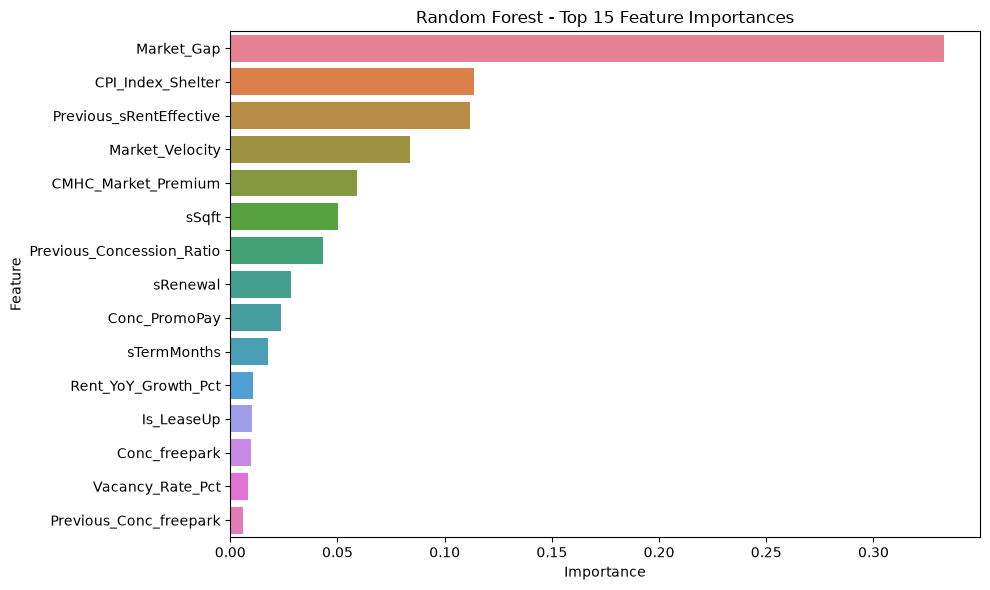

In [205]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"Random Forest R2: {r2_score(y_test, rf_pred):.4f}")

# --- Interpretability Plots ---
fig, ax = plt.subplots(figsize=(10, 6))

# RF Feature Importance
imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=False).head(15)
sns.barplot(data=imp_df, x='Importance', y='Feature', hue='Feature', legend=False)
ax.set_title('Random Forest - Top 15 Feature Importances')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

Calculating SHAP values...


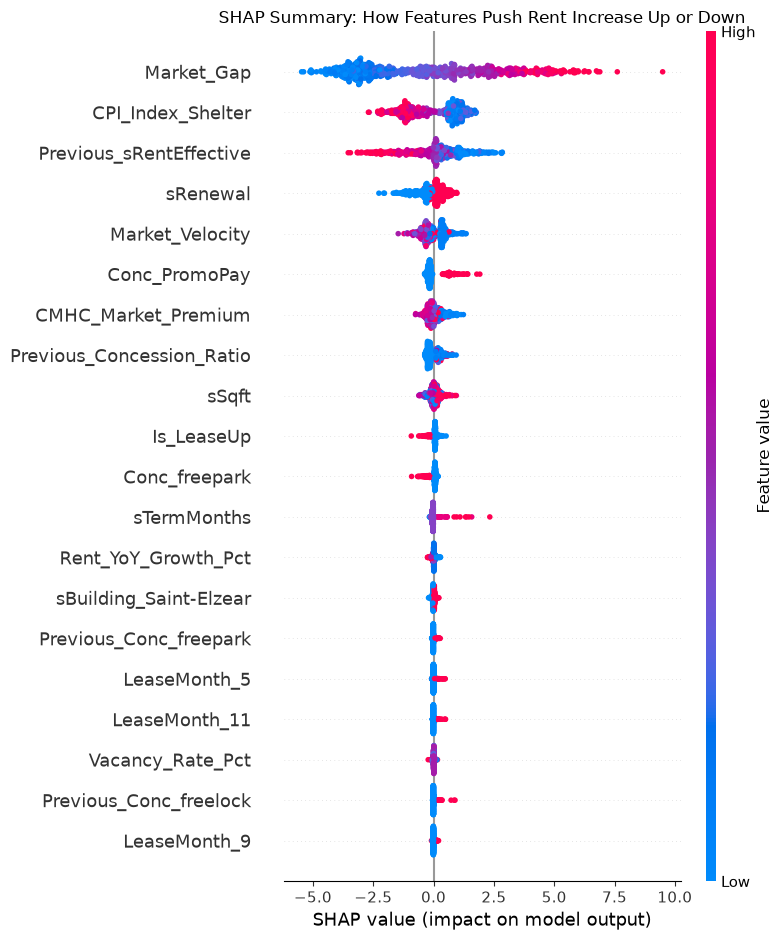

In [206]:
print("Calculating SHAP values...")
# Initialize the SHAP Explainer using your trained Random Forest
explainer = shap.TreeExplainer(rf)
# Calculate SHAP values for the test set
# (We use a sample if the dataset is huge, but yours should compute quickly)
shap_values = explainer.shap_values(X_test)
# Plot the Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: How Features Push Rent Increase Up or Down")
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()


Generating Partial Dependence Plots...


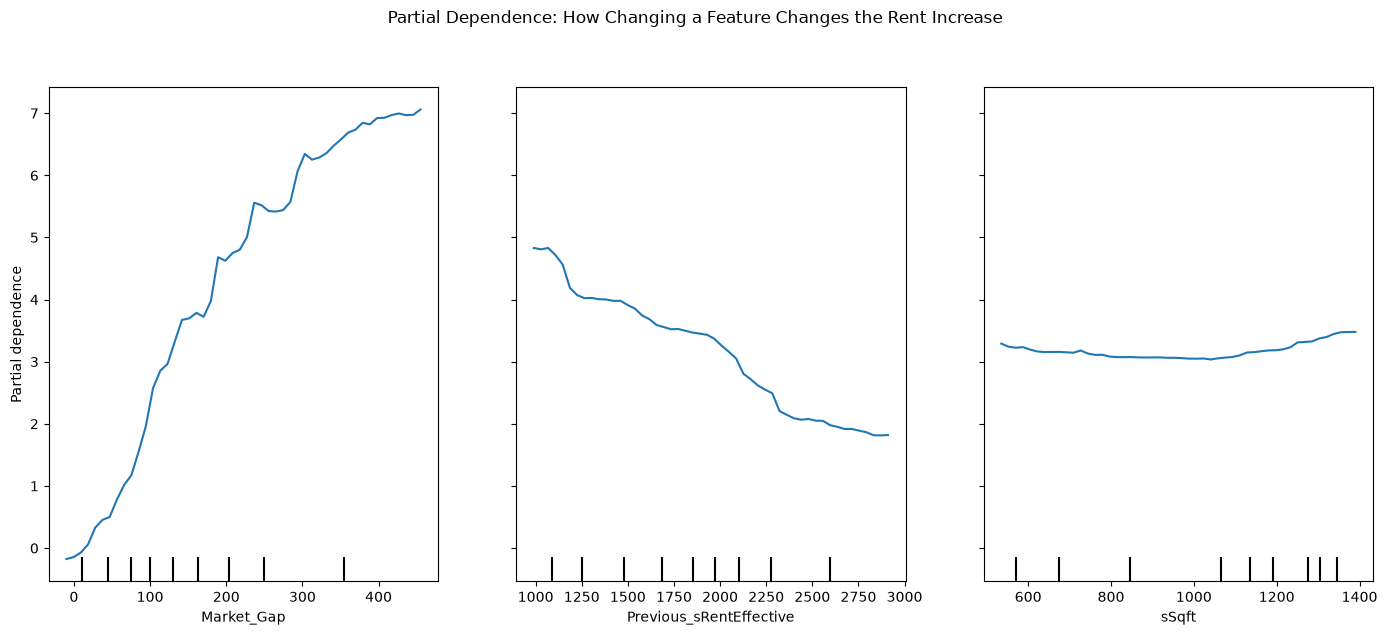

In [207]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print("\nGenerating Partial Dependence Plots...")
fig, ax = plt.subplots(figsize=(14, 6))
# Let's look at the exact curve for the top 3 continuous features
top_features_to_plot = ['Market_Gap', 'Previous_sRentEffective', 'sSqft']
PartialDependenceDisplay.from_estimator(
    estimator=rf, 
    X=X_train, 
    features=top_features_to_plot,
    feature_names=X.columns.tolist(),
    ax=ax,
    grid_resolution=50 
)
plt.suptitle("Partial Dependence: How Changing a Feature Changes the Rent Increase", y=1.05)
plt.tight_layout()
plt.show()

## Strategic Interpretation: Defining Strategies per Building and Province

The initial Random Forest model reveals that **Market Gap** is the strongest global predictor of rent increases. This confirms that historically, leasing teams operate on a "Mark-to-Market" objective—trying to close the loss-to-lease gap whenever possible.

However, to achieve the objective of defining strategies **per building** and **per province**, we must understand that this global average curve blends different realities:

1. **Provincial Regulations (Rent Control):** A $300 Market Gap in a rent-controlled province like Quebec might be legally impossible to close on a renewal, resulting in a capped increase. In a non-rent-controlled market like Alberta, that same gap could be closed entirely. Our strategy must dictate *how aggressively* to pursue the Market Gap based on provincial laws.
2. **Building-Level Pricing Power:** Premium buildings with high tenant retention can push to close the Market Gap more aggressively without risking vacancy. Lower-tier buildings might need to accept smaller increases to maintain occupancy.

**Next Step:** To uncover these localized strategies, we need to inject geographic and property identifiers (`sBuilding` and `sState`) into the model. By doing this, we can use SHAP to isolate the exact pricing power of individual buildings and the legislative caps of specific provinces.
